**A DATA-DRIVEN COMPARISON OF MACHINE LEARNING MODELS FOR PREDICTING EMPLOYEE ATTRITION INTENTION**

03 — Model Training and Comparison

This notebook covers train-test split, 10-fold stratified cross-validation, training of six machine learning models (Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, XGBoost and CatBoost), test set evaluation, confusion matrix, ROC curve and AUC analysis.

4. Machine Learning Model Training

The dataset is split into 80% training and 20% test sets using stratified sampling. Six machine learning models are trained and compared using 10-fold stratified cross-validation: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, XGBoost and CatBoost.

In [ ]:
!pip install catboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data fresh
data = pd.read_csv("Employee_Attrition_Intention_Survey_Responses.csv")
data.columns = data.columns.str.strip()

target_col = "AttritionIntention"
data[target_col] = data[target_col].astype(str).str.strip()
data[target_col] = data[target_col].map({
    "No": 0, "Yes": 1, "0": 0, "1": 1, 0: 0, 1: 1
})

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna().copy()
data[target_col] = data[target_col].astype(int)

print("After cleaning:", data.shape)
print("\nClass distribution:")
print(data[target_col].value_counts())

# Features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Define 6 models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.1,
        random_seed=42,
        verbose=0,
        auto_class_weights="Balanced"
    )
}

print("\n6 models defined successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
After cleaning: (378, 24)

Class distribution:
AttritionIntention
0    199
1    179
Name: count, dtype: int64

Train shape: (302, 23)
Test shape: (76, 23)

6 models defined successfully.


4.1 10-Fold Stratified Cross-Validation Results

In [ ]:
# =========================================================
# 10-FOLD CROSS VALIDATION ON TRAINING SET
# =========================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n========== 10-FOLD CROSS-VALIDATION RESULTS ==========")
for name, model in models.items():
    acc_scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="accuracy"
    )
    f1_scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="f1"
    )

    print(f"\n{name}")
    print("CV Accuracy:", np.round(acc_scores, 4))
    print("Mean CV Accuracy:", round(acc_scores.mean(), 4))
    print("Std Deviation:", round(acc_scores.std(), 4))
    print("Mean CV F1:", round(f1_scores.mean(), 4))


========== 10-FOLD CROSS-VALIDATION RESULTS ==========

Logistic Regression
CV Accuracy: [0.6774 0.5806 0.7    0.7    0.6667 0.5667 0.6    0.8    0.5333 0.7   ]
Mean CV Accuracy: 0.6525
Std Deviation: 0.0767
Mean CV F1: 0.615

Decision Tree
CV Accuracy: [0.6774 0.6774 0.5333 0.6667 0.5667 0.5    0.6333 0.7333 0.5    0.6333]
Mean CV Accuracy: 0.6122
Std Deviation: 0.0778
Mean CV F1: 0.5702

Random Forest
CV Accuracy: [0.6774 0.5806 0.7333 0.6333 0.7667 0.7667 0.7333 0.7667 0.5333 0.6667]
Mean CV Accuracy: 0.6858
Std Deviation: 0.0785
Mean CV F1: 0.6539

SVM
CV Accuracy: [0.7742 0.5161 0.6333 0.6333 0.5667 0.6    0.7    0.7333 0.7333 0.6333]
Mean CV Accuracy: 0.6524
Std Deviation: 0.0774
Mean CV F1: 0.6204

XGBoost
CV Accuracy: [0.6452 0.6452 0.6667 0.6333 0.7    0.6333 0.7    0.8    0.6    0.6333]
Mean CV Accuracy: 0.6657
Std Deviation: 0.0536
Mean CV F1: 0.6308

CatBoost
CV Accuracy: [0.7419 0.5806 0.7333 0.6    0.7333 0.7667 0.7667 0.7667 0.6333 0.6333]
Mean CV Accuracy: 0.6956
Std D

5. Model Evaluation

Each model is evaluated using Accuracy, Precision, Recall, and F1-Score on the held-out test set.

In [ ]:
# =========================================================
# TEST SET EVALUATION
# =========================================================
from sklearn.metrics import precision_score, recall_score

print("\n========== TEST SET RESULTS ==========")
trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results)
print("\n========== SUMMARY TABLE ==========")
print(results_df.sort_values(
    by="Accuracy", ascending=False).to_string(index=False))


========== TEST SET RESULTS ==========

Logistic Regression
Accuracy: 0.6842
Precision: 0.6765
Recall: 0.6389
F1-score: 0.6571
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        40
           1       0.68      0.64      0.66        36

    accuracy                           0.68        76
   macro avg       0.68      0.68      0.68        76
weighted avg       0.68      0.68      0.68        76

Confusion Matrix:
[[29 11]
 [13 23]]

Decision Tree
Accuracy: 0.6316
Precision: 0.6429
Recall: 0.5
F1-score: 0.5625
              precision    recall  f1-score   support

           0       0.62      0.75      0.68        40
           1       0.64      0.50      0.56        36

    accuracy                           0.63        76
   macro avg       0.63      0.62      0.62        76
weighted avg       0.63      0.63      0.63        76

Confusion Matrix:
[[30 10]
 [18 18]]

Random Forest
Accuracy: 0.75
Precision: 0.7742
Recall: 0.6667
F1

5.1 Model Accuracy Comparison

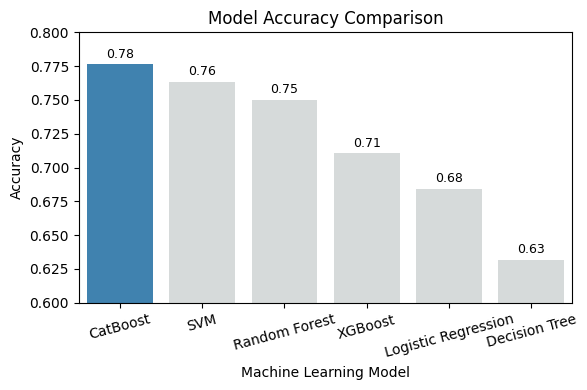

In [ ]:
results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x="Model",
    y="Accuracy",
    hue="Model",          #  add this
    data=results_df,
    palette=['#2E86C1'] + ['#D5DBDB']*(len(results_df)-1),
    legend=False          #  remove duplicate legend
)

# Add values on bars
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=9)

plt.title("Model Accuracy Comparison", fontsize=12)
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0.6, 0.8)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

5.2 ROC Curve and AUC Analysis

ROC curves and AUC values for all six models to assess overall classification performance.

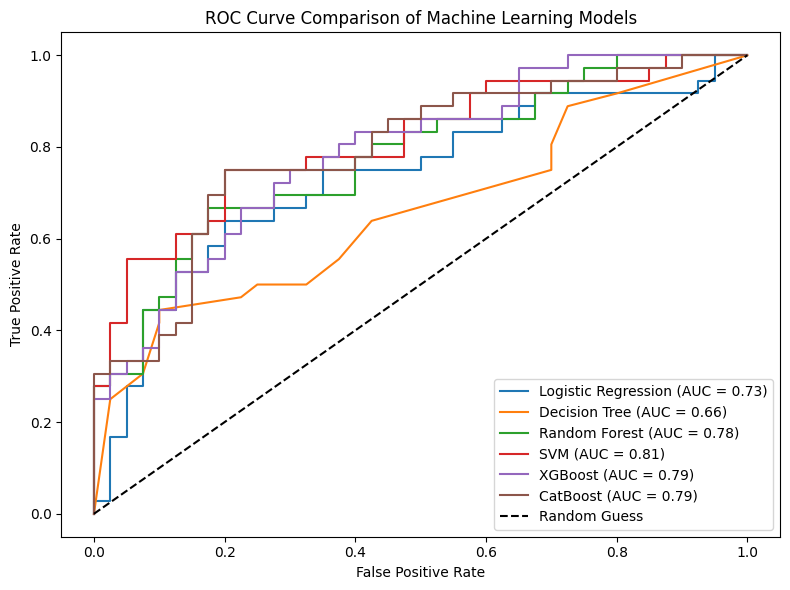

In [ ]:
# =========================================================
# ROC CURVE ANALYSIS
# =========================================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    except:
        pass

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.tight_layout()
plt.show()